In [1]:
import time
import random
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split

import torchvision
import torchvision.transforms as transforms

from sklearn.manifold import TSNE

In [2]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

print("Device:", device)

Device: cpu


In [3]:
transform_cifar = transforms.ToTensor()

cifar_train = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_cifar
)

cifar_test = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_cifar
)

TASK_A_TRAIN_SIZE = 20000
TASK_A_TEST_SIZE = 5000
BATCH_SIZE_A = 256

generator = torch.Generator().manual_seed(SEED)

train_indices = torch.randperm(
    len(cifar_train),
    generator=generator
)[:TASK_A_TRAIN_SIZE]

test_indices = torch.randperm(
    len(cifar_test),
    generator=generator
)[:TASK_A_TEST_SIZE]

cifar_train_subset = Subset(cifar_train, train_indices)
cifar_test_subset = Subset(cifar_test, test_indices)

train_loader_a = DataLoader(
    cifar_train_subset,
    batch_size=BATCH_SIZE_A,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader_a = DataLoader(
    cifar_test_subset,
    batch_size=BATCH_SIZE_A,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Task A train samples:", len(cifar_train_subset))
print("Task A test samples:", len(cifar_test_subset))

100%|██████████| 170M/170M [04:43<00:00, 602kB/s]


Task A train samples: 20000
Task A test samples: 5000


In [4]:
def dataset_to_matrix(loader):
    images = []
    labels = []

    for x, y in loader:
        images.append(x.view(x.size(0), -1))
        labels.append(y)

    images = torch.cat(images)
    labels = torch.cat(labels)

    return images, labels

svd_train_loader = DataLoader(
    cifar_train_subset,
    batch_size=512,
    shuffle=False
)

svd_test_loader = DataLoader(
    cifar_test_subset,
    batch_size=512,
    shuffle=False
)

train_matrix, train_labels_a = dataset_to_matrix(svd_train_loader)
test_matrix, test_labels_a = dataset_to_matrix(svd_test_loader)

print("Train matrix:", train_matrix.shape)
print("Test matrix:", test_matrix.shape)

Train matrix: torch.Size([20000, 3072])
Test matrix: torch.Size([5000, 3072])


In [5]:
LATENT_A = 64

train_matrix_gpu = train_matrix.to(device)
test_matrix_gpu = test_matrix.to(device)

svd_mean = train_matrix_gpu.mean(dim=0, keepdim=True)

train_centered = train_matrix_gpu - svd_mean
test_centered = test_matrix_gpu - svd_mean

_, _, svd_v = torch.svd_lowrank(
    train_centered,
    q=LATENT_A,
    niter=2
)

svd_latent = test_centered @ svd_v
svd_reconstruction = svd_latent @ svd_v.T + svd_mean

svd_mse = F.mse_loss(
    svd_reconstruction,
    test_matrix_gpu
).item()

svd_latent_cpu = svd_latent.cpu().numpy()

print("SVD latent shape:", svd_latent.shape)
print(f"SVD test MSE: {svd_mse:.6f}")

SVD latent shape: torch.Size([5000, 64])
SVD test MSE: 0.008719


In [6]:
class LinearAutoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()

        self.encoder = nn.Linear(3072, latent_dim)
        self.decoder = nn.Linear(latent_dim, 3072)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        z = self.encoder(x)
        reconstruction = self.decoder(z)

        return reconstruction

    def encode(self, x):
        x = x.view(x.size(0), -1)

        return self.encoder(x)

In [7]:
class NonlinearAutoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(3072, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 3072),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        z = self.encoder(x)

        return self.decoder(z)

    def encode(self, x):
        x = x.view(x.size(0), -1)

        return self.encoder(x)

In [8]:
def evaluate_autoencoder(model, loader):
    model.eval()

    total_squared_error = 0
    total_values = 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            target = x.view(x.size(0), -1)

            reconstruction = model(x)

            total_squared_error += F.mse_loss(
                reconstruction,
                target,
                reduction="sum"
            ).item()

            total_values += target.numel()

    return total_squared_error / total_values


def train_autoencoder(model, train_loader, test_loader, epochs=12):
    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    history = []

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        total_values = 0

        for x, _ in train_loader:
            x = x.to(device)
            target = x.view(x.size(0), -1)

            optimizer.zero_grad()

            reconstruction = model(x)

            loss = F.mse_loss(
                reconstruction,
                target
            )

            loss.backward()
            optimizer.step()

            total_loss += F.mse_loss(
                reconstruction.detach(),
                target,
                reduction="sum"
            ).item()

            total_values += target.numel()

        train_mse = total_loss / total_values
        test_mse = evaluate_autoencoder(model, test_loader)

        history.append((train_mse, test_mse))

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"train MSE {train_mse:.6f} | "
            f"test MSE {test_mse:.6f}"
        )

    return model, history

In [9]:
set_seed()

linear_ae = LinearAutoencoder(
    latent_dim=LATENT_A
).to(device)

linear_ae, linear_history = train_autoencoder(
    linear_ae,
    train_loader_a,
    test_loader_a,
    epochs=12
)

set_seed()

nonlinear_ae = NonlinearAutoencoder(
    latent_dim=LATENT_A
).to(device)

nonlinear_ae, nonlinear_history = train_autoencoder(
    nonlinear_ae,
    train_loader_a,
    test_loader_a,
    epochs=12
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/12 | train MSE 0.145323 | test MSE 0.047369
Epoch 02/12 | train MSE 0.045910 | test MSE 0.045079
Epoch 03/12 | train MSE 0.042570 | test MSE 0.040244
Epoch 04/12 | train MSE 0.037296 | test MSE 0.035347
Epoch 05/12 | train MSE 0.033360 | test MSE 0.032255
Epoch 06/12 | train MSE 0.030756 | test MSE 0.029880
Epoch 07/12 | train MSE 0.028670 | test MSE 0.027678
Epoch 08/12 | train MSE 0.026567 | test MSE 0.025690
Epoch 09/12 | train MSE 0.024527 | test MSE 0.023965
Epoch 10/12 | train MSE 0.022958 | test MSE 0.022980
Epoch 11/12 | train MSE 0.022112 | test MSE 0.021665
Epoch 12/12 | train MSE 0.020908 | test MSE 0.021000
Epoch 01/12 | train MSE 0.044295 | test MSE 0.033282
Epoch 02/12 | train MSE 0.030468 | test MSE 0.027348
Epoch 03/12 | train MSE 0.025471 | test MSE 0.024915
Epoch 04/12 | train MSE 0.023724 | test MSE 0.023737
Epoch 05/12 | train MSE 0.022714 | test MSE 0.023398
Epoch 06/12 | train MSE 0.021525 | test MSE 0.021626
Epoch 07/12 | train MSE 0.020587 | test MSE 0.

In [10]:
linear_mse = evaluate_autoencoder(
    linear_ae,
    test_loader_a
)

nonlinear_mse = evaluate_autoencoder(
    nonlinear_ae,
    test_loader_a
)

task_a_results = pd.DataFrame({
    "Method": [
        "SVD",
        "Linear Autoencoder",
        "Non-linear Autoencoder"
    ],
    "Latent Dimension": [
        LATENT_A,
        LATENT_A,
        LATENT_A
    ],
    "Test MSE": [
        svd_mse,
        linear_mse,
        nonlinear_mse
    ]
})

task_a_results

,Method,Latent Dimension,Test MSE
0,SVD,64,0.008719
1,Linear Autoencoder,64,0.021000
2,Non-linear Autoencoder,64,0.018087


In [11]:
def collect_latent(model, loader):
    model.eval()

    latent_values = []
    labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            z = model.encode(x)

            latent_values.append(z.cpu())
            labels.append(y)

    latent_values = torch.cat(latent_values).numpy()
    labels = torch.cat(labels).numpy()

    return latent_values, labels


linear_latent, latent_labels = collect_latent(
    linear_ae,
    test_loader_a
)

nonlinear_latent, _ = collect_latent(
    nonlinear_ae,
    test_loader_a
)

print("SVD:", svd_latent_cpu.shape)
print("Linear AE:", linear_latent.shape)
print("Non-linear AE:", nonlinear_latent.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


SVD: (5000, 64)
Linear AE: (5000, 64)
Non-linear AE: (5000, 64)


In [12]:
TSNE_SAMPLES = 2000

representations = {
    "SVD": svd_latent_cpu[:TSNE_SAMPLES],
    "Linear Autoencoder": linear_latent[:TSNE_SAMPLES],
    "Non-linear Autoencoder": nonlinear_latent[:TSNE_SAMPLES]
}

tsne_labels = latent_labels[:TSNE_SAMPLES]

tsne_results = {}

for name, representation in representations.items():
    print("Running t-SNE for", name)

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        max_iter=1000,
        random_state=SEED
    )

    tsne_results[name] = tsne.fit_transform(
        representation
    )

Running t-SNE for SVD
Running t-SNE for Linear Autoencoder
Running t-SNE for Non-linear Autoencoder


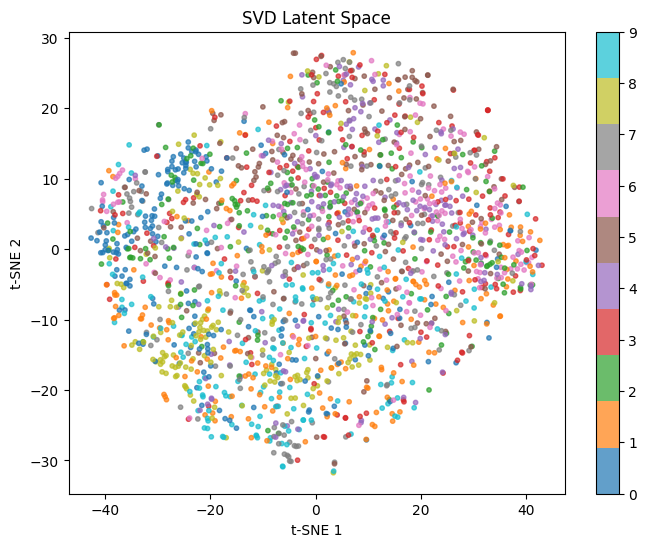

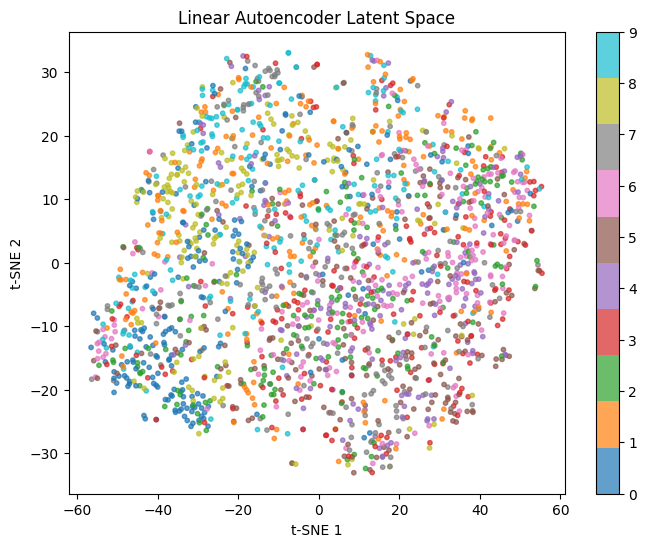

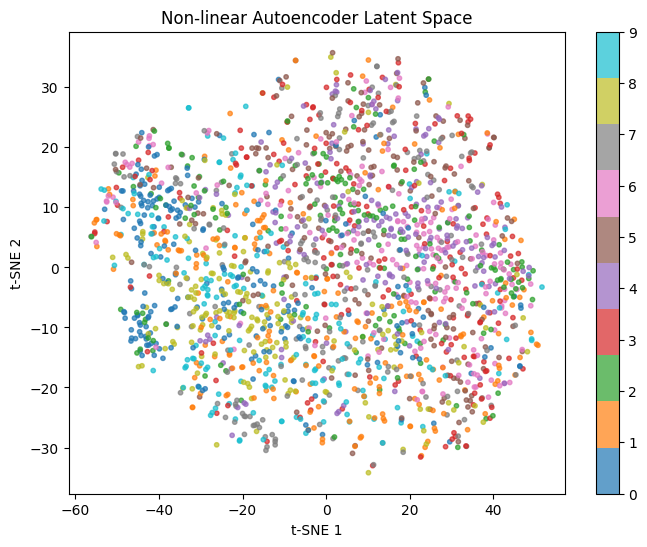

In [13]:
for name, points in tsne_results.items():
    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        points[:, 0],
        points[:, 1],
        c=tsne_labels,
        s=10,
        alpha=0.7,
        cmap="tab10"
    )

    plt.colorbar(scatter)
    plt.title(f"{name} Latent Space")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.show()

In [14]:
transform_fashion = transforms.ToTensor()

fashion_full_train = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform_fashion
)

fashion_test = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform_fashion
)

train_size = 50000
val_size = 10000

fashion_train, fashion_val = random_split(
    fashion_full_train,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

BATCH_SIZE_B = 256

fashion_train_loader = DataLoader(
    fashion_train,
    batch_size=BATCH_SIZE_B,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

fashion_val_loader = DataLoader(
    fashion_val,
    batch_size=BATCH_SIZE_B,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

fashion_test_loader = DataLoader(
    fashion_test,
    batch_size=BATCH_SIZE_B,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train:", len(fashion_train))
print("Validation:", len(fashion_val))
print("Test:", len(fashion_test))

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 270kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.03MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.1MB/s]

Train: 50000
Validation: 10000
Test: 10000


In [15]:
LATENT_B = 20

vae_configs = {
    "Base": {
        "encoder": [400, 100],
        "decoder": [100, 400]
    },
    "Deeper": {
        "encoder": [400, 100, 50],
        "decoder": [50, 100, 400]
    },
    "Wider": {
        "encoder": [600, 200],
        "decoder": [200, 600]
    }
}


class VAE(nn.Module):
    def __init__(
        self,
        encoder_dims,
        decoder_dims,
        latent_dim=20
    ):
        super().__init__()

        encoder_layers = []
        previous = 784

        for size in encoder_dims:
            encoder_layers.append(
                nn.Linear(previous, size)
            )
            encoder_layers.append(nn.ReLU())
            previous = size

        self.encoder_net = nn.Sequential(
            *encoder_layers
        )

        self.fc_mu = nn.Linear(
            previous,
            latent_dim
        )

        self.fc_logvar = nn.Linear(
            previous,
            latent_dim
        )

        decoder_layers = []
        previous = latent_dim

        for size in decoder_dims:
            decoder_layers.append(
                nn.Linear(previous, size)
            )
            decoder_layers.append(nn.ReLU())
            previous = size

        decoder_layers.append(
            nn.Linear(previous, 784)
        )
        decoder_layers.append(nn.Sigmoid())

        self.decoder = nn.Sequential(
            *decoder_layers
        )

    def encode(self, x):
        x = x.view(x.size(0), -1)

        h = self.encoder_net(x)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)

        z = self.reparameterize(
            mu,
            logvar
        )

        reconstruction = self.decode(z)

        return reconstruction, mu, logvar

In [16]:
def vae_loss(reconstruction, target, mu, logvar):
    reconstruction_loss = F.mse_loss(
        reconstruction,
        target,
        reduction="sum"
    )

    kl_loss = -0.5 * torch.sum(
        1
        + logvar
        - mu.pow(2)
        - logvar.exp()
    )

    total_loss = reconstruction_loss + kl_loss

    return (
        total_loss,
        reconstruction_loss,
        kl_loss
    )


def evaluate_vae(model, loader):
    model.eval()

    total_loss = 0
    total_reconstruction = 0
    total_kl = 0
    total_samples = 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            target = x.view(x.size(0), -1)

            reconstruction, mu, logvar = model(x)

            loss, recon_loss, kl_loss = vae_loss(
                reconstruction,
                target,
                mu,
                logvar
            )

            total_loss += loss.item()
            total_reconstruction += recon_loss.item()
            total_kl += kl_loss.item()
            total_samples += x.size(0)

    return (
        total_loss / total_samples,
        total_reconstruction / total_samples,
        total_kl / total_samples
    )

In [17]:
def train_vae(model, train_loader, val_loader, epochs=15):
    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    best_val_loss = float("inf")
    best_state = None

    history = []

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        total_samples = 0

        for x, _ in train_loader:
            x = x.to(device)
            target = x.view(x.size(0), -1)

            optimizer.zero_grad()

            reconstruction, mu, logvar = model(x)

            loss, _, _ = vae_loss(
                reconstruction,
                target,
                mu,
                logvar
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_samples += x.size(0)

        train_loss = total_loss / total_samples

        val_loss, val_recon, val_kl = evaluate_vae(
            model,
            val_loader
        )

        history.append({
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_reconstruction": val_recon,
            "val_kl": val_kl
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(
                model.state_dict()
            )

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"train {train_loss:.4f} | "
            f"val {val_loss:.4f} | "
            f"recon {val_recon:.4f} | "
            f"KL {val_kl:.4f}"
        )

    model.load_state_dict(best_state)

    return model, history

In [18]:
VAE_EPOCHS = 15

vae_models = {}
vae_histories = {}
vae_results = []

for name, config in vae_configs.items():
    print(f"\nTraining {name} VAE")

    set_seed()

    model = VAE(
        encoder_dims=config["encoder"],
        decoder_dims=config["decoder"],
        latent_dim=LATENT_B
    )

    start = time.perf_counter()

    model, history = train_vae(
        model,
        fashion_train_loader,
        fashion_val_loader,
        epochs=VAE_EPOCHS
    )

    elapsed = time.perf_counter() - start

    test_total, test_recon, test_kl = evaluate_vae(
        model,
        fashion_test_loader
    )

    vae_models[name] = model
    vae_histories[name] = history

    vae_results.append({
        "Architecture": name,
        "Test Total Loss": test_total,
        "Test Reconstruction Loss": test_recon,
        "Test KL Loss": test_kl,
        "Parameters": count_parameters(model),
        "Training Time (s)": elapsed
    })

    print(
        f"{name}: "
        f"total={test_total:.4f}, "
        f"recon={test_recon:.4f}, "
        f"KL={test_kl:.4f}"
    )


Training Base VAE


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/15 | train 52.4324 | val 38.9862 | recon 32.5731 | KL 6.4131
Epoch 02/15 | train 34.4394 | val 31.4016 | recon 25.0334 | KL 6.3682
Epoch 03/15 | train 29.8042 | val 28.9498 | recon 22.3194 | KL 6.6303
Epoch 04/15 | train 28.2262 | val 28.2464 | recon 22.1997 | KL 6.0466
Epoch 05/15 | train 27.3473 | val 27.0427 | recon 20.4812 | KL 6.5616
Epoch 06/15 | train 26.7147 | val 26.4562 | recon 19.9644 | KL 6.4918
Epoch 07/15 | train 26.1419 | val 25.9345 | recon 19.1709 | KL 6.7636
Epoch 08/15 | train 25.7421 | val 25.8056 | recon 18.9328 | KL 6.8728
Epoch 09/15 | train 25.3863 | val 25.4666 | recon 18.4830 | KL 6.9836
Epoch 10/15 | train 25.1154 | val 25.1863 | recon 18.2698 | KL 6.9165
Epoch 11/15 | train 24.9347 | val 25.0054 | recon 17.5707 | KL 7.4347
Epoch 12/15 | train 24.7822 | val 24.8077 | recon 17.7766 | KL 7.0311
Epoch 13/15 | train 24.5911 | val 25.2504 | recon 17.5731 | KL 7.6773
Epoch 14/15 | train 24.4602 | val 24.6835 | recon 17.5947 | KL 7.0888
Epoch 15/15 | train 

In [19]:
vae_results_df = pd.DataFrame(
    vae_results
)

vae_results_df

,Architecture,Test Total Loss,Test Reconstruction Loss,Test KL Loss,Parameters,Training Time (s)
0,Base,24.589814,17.442151,7.147663,715024,188.172120
1,Deeper,25.380681,19.262209,6.118472,722124,197.579951
2,Wider,24.262745,16.633475,7.629270,1195224,232.895777


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


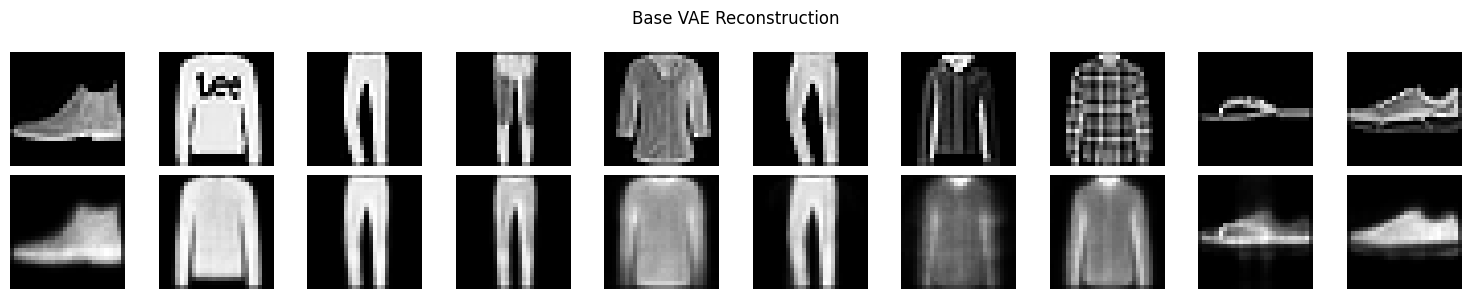

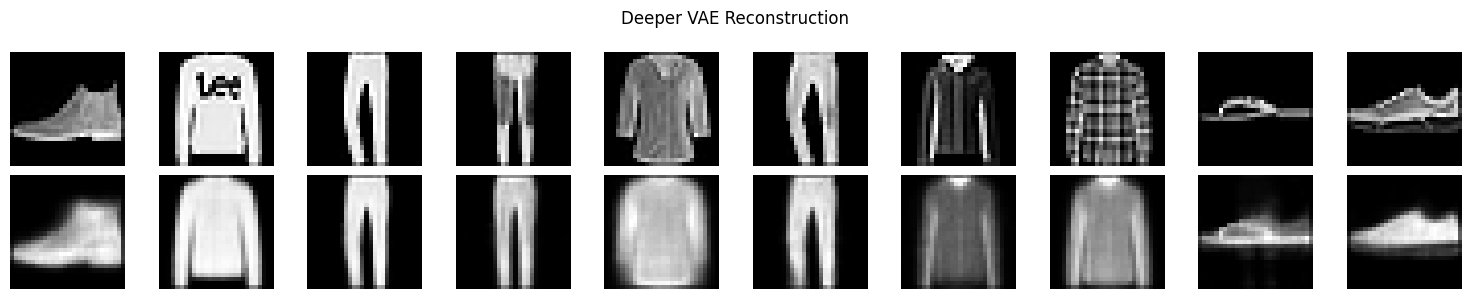

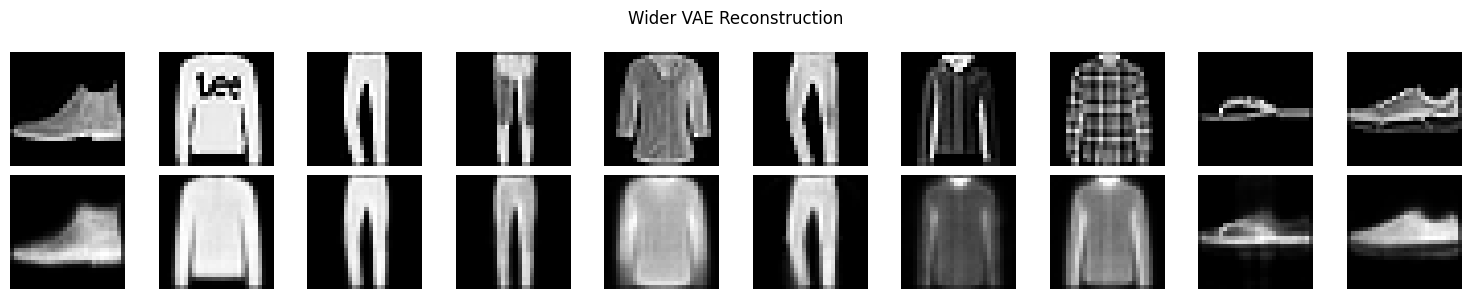

In [20]:
def plot_reconstruction(
    model,
    loader,
    title,
    n=10,
    is_vae=True
):
    model.eval()

    x, _ = next(iter(loader))
    x = x[:n].to(device)

    with torch.no_grad():
        if is_vae:
            mu, _ = model.encode(x)
            reconstruction = model.decode(mu)
        else:
            reconstruction = model(x)

    reconstruction = reconstruction.view(
        -1,
        1,
        28,
        28
    )

    x = x.cpu()
    reconstruction = reconstruction.cpu()

    plt.figure(figsize=(15, 3))

    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(
            x[i, 0],
            cmap="gray"
        )
        plt.axis("off")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(
            reconstruction[i, 0],
            cmap="gray"
        )
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


for name, model in vae_models.items():
    plot_reconstruction(
        model,
        fashion_test_loader,
        f"{name} VAE Reconstruction"
    )

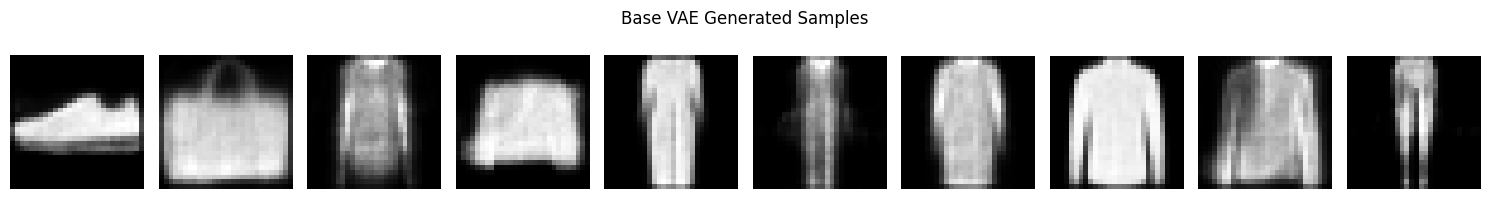

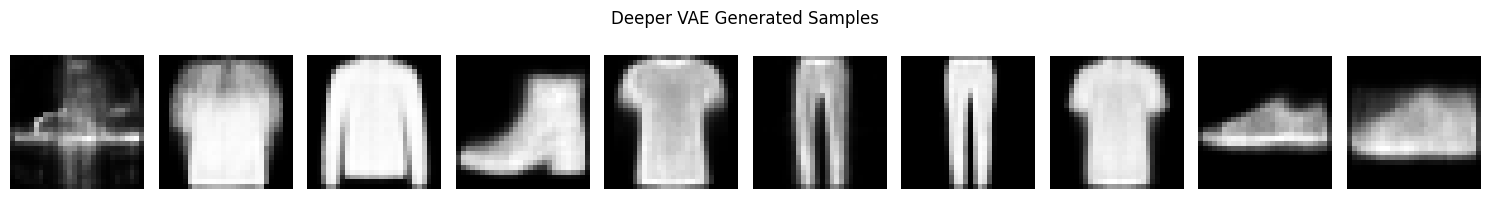

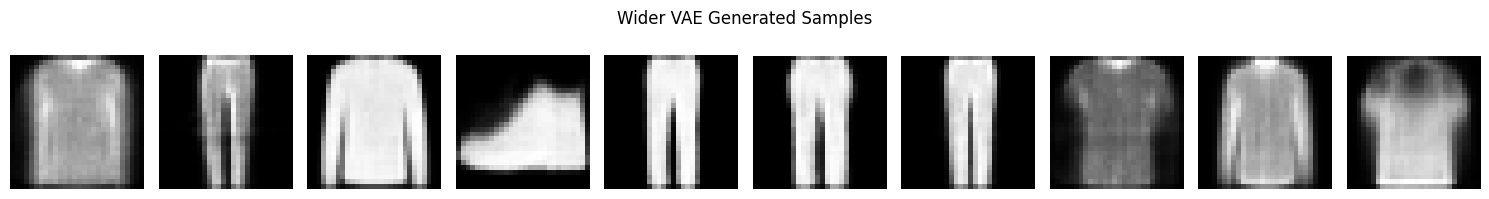

In [21]:
def plot_generation(
    model,
    title,
    n=10
):
    model.eval()

    z = torch.randn(
        n,
        LATENT_B,
        device=device
    )

    with torch.no_grad():
        samples = model.decode(z)

    samples = samples.view(
        -1,
        1,
        28,
        28
    ).cpu()

    plt.figure(figsize=(15, 2))

    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(
            samples[i, 0],
            cmap="gray"
        )
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


for name, model in vae_models.items():
    plot_generation(
        model,
        f"{name} VAE Generated Samples"
    )

In [22]:
def get_class_image(dataset, class_id):
    for image, label in dataset:
        if label == class_id:
            return image.unsqueeze(0)


def plot_latent_traversal(
    model,
    dataset,
    class_a=0,
    class_b=9,
    steps=10,
    title=""
):
    model.eval()

    image_a = get_class_image(
        dataset,
        class_a
    ).to(device)

    image_b = get_class_image(
        dataset,
        class_b
    ).to(device)

    with torch.no_grad():
        mu_a, _ = model.encode(image_a)
        mu_b, _ = model.encode(image_b)

        alphas = torch.linspace(
            0,
            1,
            steps,
            device=device
        )

        latent_points = []

        for alpha in alphas:
            z = (
                (1 - alpha) * mu_a
                + alpha * mu_b
            )

            latent_points.append(z)

        latent_points = torch.cat(
            latent_points,
            dim=0
        )

        images = model.decode(
            latent_points
        )

    images = images.view(
        -1,
        1,
        28,
        28
    ).cpu()

    plt.figure(figsize=(15, 2))

    for i in range(steps):
        plt.subplot(1, steps, i + 1)
        plt.imshow(
            images[i, 0],
            cmap="gray"
        )
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

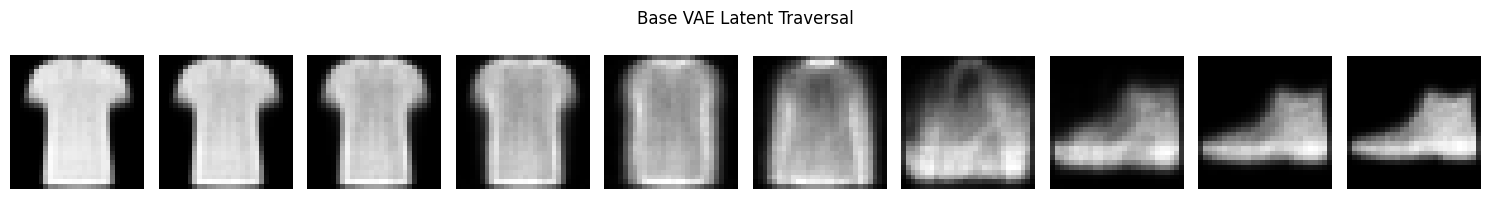

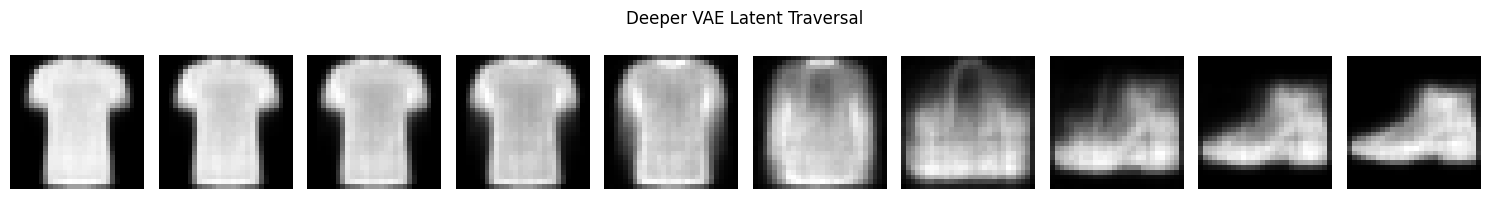

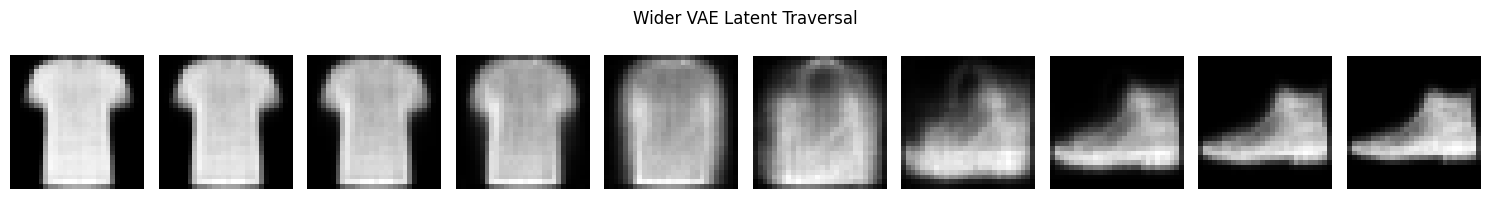

In [23]:
for name, model in vae_models.items():
    plot_latent_traversal(
        model,
        fashion_test,
        class_a=0,
        class_b=9,
        steps=10,
        title=f"{name} VAE Latent Traversal"
    )

In [24]:
best_vae_name = None
best_vae_val_loss = float("inf")

for name in vae_models:
    history = vae_histories[name]

    best_loss = min(
        row["val_loss"]
        for row in history
    )

    if best_loss < best_vae_val_loss:
        best_vae_val_loss = best_loss
        best_vae_name = name

best_vae = vae_models[
    best_vae_name
]

best_config = vae_configs[
    best_vae_name
]

print("Best VAE architecture:", best_vae_name)
print(
    "Best validation loss:",
    round(best_vae_val_loss, 4)
)

Best VAE architecture: Wider
Best validation loss: 24.255


In [25]:
class StandardAutoencoder(nn.Module):
    def __init__(
        self,
        encoder_dims,
        decoder_dims,
        latent_dim=20
    ):
        super().__init__()

        encoder_layers = []
        previous = 784

        for size in encoder_dims:
            encoder_layers.append(
                nn.Linear(previous, size)
            )
            encoder_layers.append(nn.ReLU())
            previous = size

        encoder_layers.append(
            nn.Linear(previous, latent_dim)
        )

        self.encoder = nn.Sequential(
            *encoder_layers
        )

        decoder_layers = []
        previous = latent_dim

        for size in decoder_dims:
            decoder_layers.append(
                nn.Linear(previous, size)
            )
            decoder_layers.append(nn.ReLU())
            previous = size

        decoder_layers.append(
            nn.Linear(previous, 784)
        )
        decoder_layers.append(nn.Sigmoid())

        self.decoder = nn.Sequential(
            *decoder_layers
        )

    def encode(self, x):
        x = x.view(x.size(0), -1)

        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)

        return self.decode(z)

In [26]:
def evaluate_standard_ae(model, loader):
    model.eval()

    total_loss = 0
    total_samples = 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            target = x.view(x.size(0), -1)

            reconstruction = model(x)

            loss = F.mse_loss(
                reconstruction,
                target,
                reduction="sum"
            )

            total_loss += loss.item()
            total_samples += x.size(0)

    return total_loss / total_samples


def train_standard_ae(
    model,
    train_loader,
    val_loader,
    epochs=15
):
    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    best_val_loss = float("inf")
    best_state = None

    history = []

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        total_samples = 0

        for x, _ in train_loader:
            x = x.to(device)
            target = x.view(x.size(0), -1)

            optimizer.zero_grad()

            reconstruction = model(x)

            loss = F.mse_loss(
                reconstruction,
                target,
                reduction="sum"
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_samples += x.size(0)

        train_loss = (
            total_loss / total_samples
        )

        val_loss = evaluate_standard_ae(
            model,
            val_loader
        )

        history.append({
            "train_loss": train_loss,
            "val_loss": val_loss
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(
                model.state_dict()
            )

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"train MSE {train_loss:.4f} | "
            f"val MSE {val_loss:.4f}"
        )

    model.load_state_dict(best_state)

    return model, history

In [27]:
set_seed()

standard_ae = StandardAutoencoder(
    encoder_dims=best_config["encoder"],
    decoder_dims=best_config["decoder"],
    latent_dim=LATENT_B
).to(device)

standard_ae, standard_ae_history = train_standard_ae(
    standard_ae,
    fashion_train_loader,
    fashion_val_loader,
    epochs=15
)

Epoch 01/15 | train MSE 35.1275 | val MSE 19.6029
Epoch 02/15 | train MSE 17.3040 | val MSE 16.2803
Epoch 03/15 | train MSE 14.8395 | val MSE 14.0547
Epoch 04/15 | train MSE 13.2731 | val MSE 12.8627
Epoch 05/15 | train MSE 12.2148 | val MSE 12.3718
Epoch 06/15 | train MSE 11.4582 | val MSE 11.3582
Epoch 07/15 | train MSE 10.8501 | val MSE 10.7858
Epoch 08/15 | train MSE 10.4031 | val MSE 10.5500
Epoch 09/15 | train MSE 10.0763 | val MSE 11.0615
Epoch 10/15 | train MSE 9.7973 | val MSE 9.8911
Epoch 11/15 | train MSE 9.4956 | val MSE 9.6812
Epoch 12/15 | train MSE 9.2508 | val MSE 9.4449
Epoch 13/15 | train MSE 9.0322 | val MSE 9.1503
Epoch 14/15 | train MSE 8.8229 | val MSE 9.0204
Epoch 15/15 | train MSE 8.6306 | val MSE 8.8204


In [28]:
ae_test_mse = evaluate_standard_ae(
    standard_ae,
    fashion_test_loader
)

vae_test_total, vae_test_recon, vae_test_kl = (
    evaluate_vae(
        best_vae,
        fashion_test_loader
    )
)

comparison_c = pd.DataFrame({
    "Model": [
        f"{best_vae_name} VAE",
        "Standard Autoencoder"
    ],
    "Reconstruction Loss": [
        vae_test_recon,
        ae_test_mse
    ],
    "KL Loss": [
        vae_test_kl,
        0.0
    ],
    "Total Loss": [
        vae_test_total,
        ae_test_mse
    ]
})

comparison_c

,Model,Reconstruction Loss,KL Loss,Total Loss
0,Wider VAE,16.592694,7.62927,24.221964
1,Standard Autoencoder,8.805940,0.00000,8.805940


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


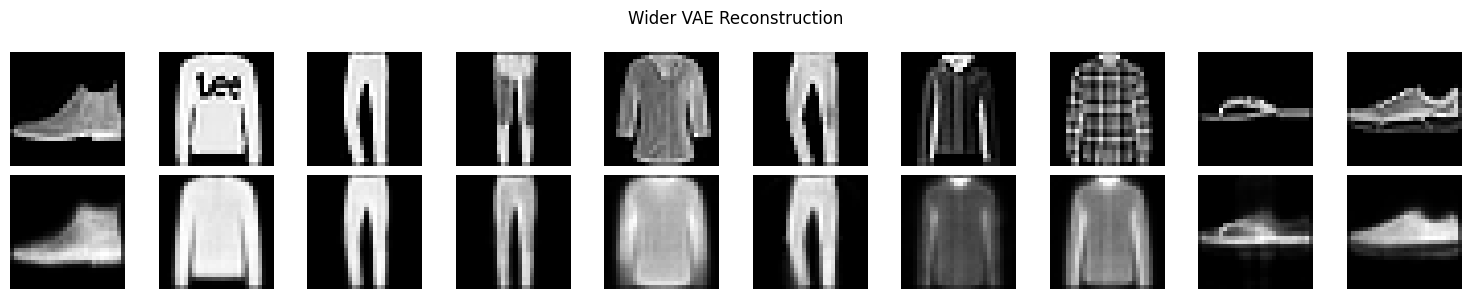

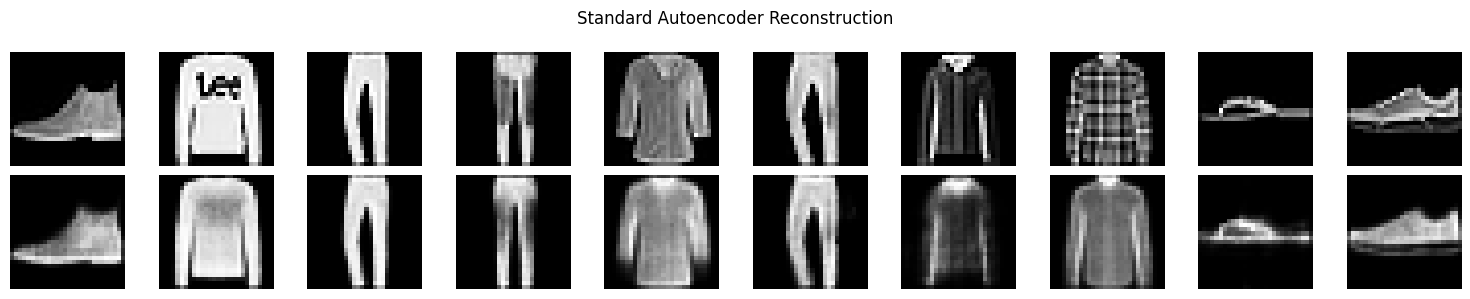

In [29]:
plot_reconstruction(
    best_vae,
    fashion_test_loader,
    f"{best_vae_name} VAE Reconstruction",
    is_vae=True
)

plot_reconstruction(
    standard_ae,
    fashion_test_loader,
    "Standard Autoencoder Reconstruction",
    is_vae=False
)

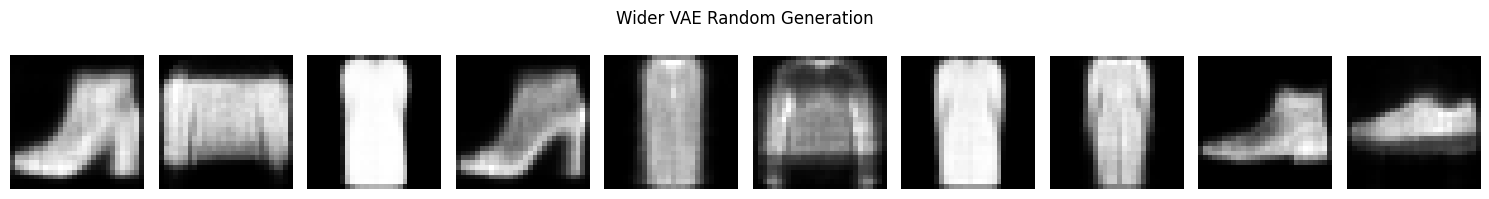

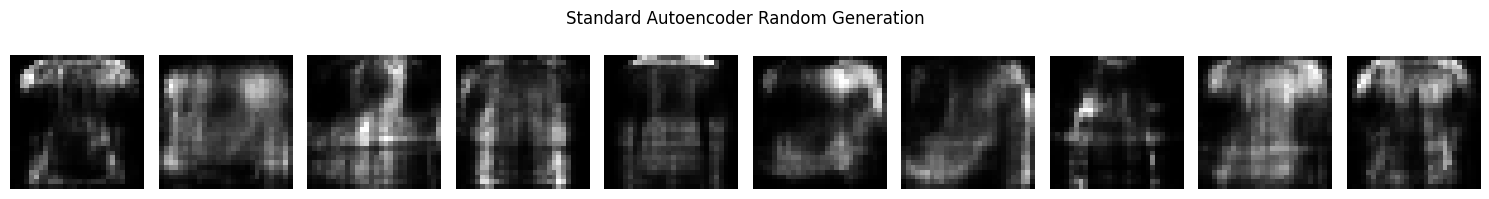

In [30]:
plot_generation(
    best_vae,
    f"{best_vae_name} VAE Random Generation"
)

z = torch.randn(
    10,
    LATENT_B,
    device=device
)

standard_ae.eval()

with torch.no_grad():
    ae_samples = standard_ae.decode(z)

ae_samples = ae_samples.view(
    -1,
    1,
    28,
    28
).cpu()

plt.figure(figsize=(15, 2))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(
        ae_samples[i, 0],
        cmap="gray"
    )
    plt.axis("off")

plt.suptitle(
    "Standard Autoencoder Random Generation"
)

plt.tight_layout()
plt.show()